# Base Notebook to re-create ovrlpy pipeline figures 

This notebook is the base notebook for 10X's Xenium brain showcase tissue sample. It runs the standard ovrlpy pipeline and saves the results to be used in further analysis.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import pandas as pd
import polars as pl
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys

import matplotlib

sys.path.append("../..")


from ovrlpy._plotting import BIH_CMAP

from utils import (
    CM,
    FONT,
    celltype_consistency,
    label_kwargs,
    plot_celltype_consistency,
    read_mapmycells_zip,
    save_kwargs,
)

matplotlib.rc("font", **FONT)

In [4]:
data_folder = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

### Data loader:

In [5]:
import pickle

with open("../xenium_brain.pickle", "rb") as file:
    brain = pickle.load(file)

coordinate_df = brain.transcripts.to_pandas().set_index("transcript_id")
signal_integrity = brain.integrity_map
signal_strength = brain.signal_map

In [6]:
signatures = pd.read_csv("../signatures.csv")

In [7]:
def anndata_from_mtx(path):
    import scipy as sp

    mtx = sp.io.mmread(path / "cell_feature_matrix/matrix.mtx").transpose().tocsr()
    obs = pd.read_parquet(path / "cells.parquet").set_index("cell_id", drop=False)
    obs.index.name += "_"
    var = pd.read_csv(
        path / "cell_feature_matrix/features.tsv",
        header=None,
        index_col=1,
        names=["gene_id", "gene", "feature_type"],
        sep="\t",
    )

    adata = ad.AnnData(mtx, obs=obs, var=var)
    adata = adata[:, adata.var["feature_type"] == "Gene Expression"]

    return adata.copy()


adata = anndata_from_mtx(data_folder)
adata

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 162033 × 248
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
    var: 'gene_id', 'feature_type'

In [8]:
# reduce size for up/download to mapmycells
temp = adata.copy()
temp.X = temp.X.astype("int32")
temp.obs = temp.obs[[]]
temp.var = temp.var[[]]
temp.write_h5ad("whole_count_mtx.h5ad", compression="gzip")
del temp

In [9]:
from shapely.geometry import Polygon

nucleus_boundaries = pl.read_parquet(data_folder / "nucleus_boundaries.parquet").filter(
    pl.col("cell_id").is_in(adata.obs["cell_id"])
)

boundaries = (
    nucleus_boundaries.lazy()
    .select("cell_id", pl.concat_arr(["vertex_x", "vertex_y"]).alias("coords"))
    .group_by("cell_id")
    .agg(pl.col("coords"))
    .collect()
)

polygons = [
    (Polygon(np.asarray(coords)), cell_id) for cell_id, coords in boundaries.iter_rows()
]

In [10]:
from rasterio.features import rasterize
from rasterio.transform import from_origin

# ensure same dimensions as the ovrlpy map
origin = (
    ovrlpy.io.read_Xenium(data_folder / "transcripts.parquet").select(("x", "y")).min()
)
transform = from_origin(origin["x"][0], origin["y"][0], 1, -1)
segmentation_map = rasterize(
    polygons,
    out_shape=signal_integrity.shape,
    fill=-1,
    transform=transform,
    all_touched=True,
    dtype=int,
)

In [11]:
signal_integrity_integration_mask = (signal_strength > 1.5) & (segmentation_map > 0)

stats = (
    pd.DataFrame(
        {
            "signal_integrity": signal_integrity[signal_integrity_integration_mask],
            "segmentation_map": segmentation_map[signal_integrity_integration_mask],
        }
    )
    .groupby("segmentation_map")
    .agg(mean_integrity=("signal_integrity", "mean"))
)

adata.obs = pd.merge(adata.obs, stats, left_on="cell_id", right_index=True, how="left")

del stats

In [12]:
adata.obs["x_centroid"] -= origin["x"][0]
adata.obs["y_centroid"] -= origin["y"][0]

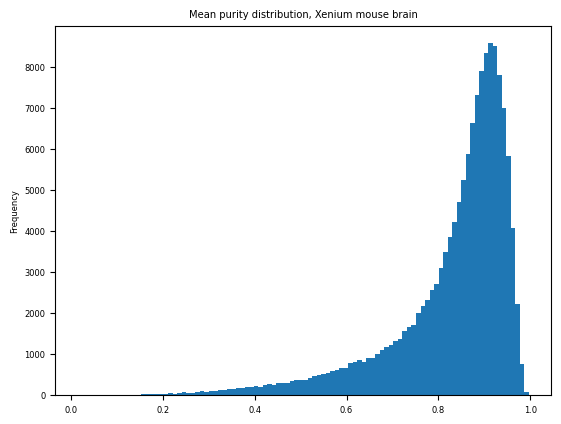

In [13]:
_ = adata.obs["mean_integrity"].plot.hist(
    bins=100, title="Mean purity distribution, Xenium mouse brain"
)

#### Create count matrices for use in mapmycells:

In [14]:
nuclear_df = coordinate_df.loc[lambda df: df["overlaps_nucleus"] == 1]

nucleus_coordinates = (
    nuclear_df[["x", "y", "cell_id"]].groupby("cell_id").mean().add_prefix("nucleus_")
)
nucleus_coordinates.index = nucleus_coordinates.index.astype(str)

adata.obs = adata.obs.join(nucleus_coordinates, how="left")

adata.obs["nuclear_integrity"] = np.nan
adata.obs.loc[~adata.obs["nucleus_x"].isna(), "nuclear_integrity"] = signal_integrity[
    adata.obs["nucleus_y"].dropna().astype(int),
    adata.obs["nucleus_x"].dropna().astype(int),
]

In [15]:
def gene_counts(df):
    return (
        df.groupby(["gene", "cell_id"], observed=True)
        .size()
        .to_frame("n")
        .reset_index("gene")
        .pivot(columns="gene", values="n")
        .fillna(0)
        .astype("int16")
    )


bottom_count_mtx = gene_counts(nuclear_df[nuclear_df["z"] < nuclear_df["z_center"]])
top_count_mtx = gene_counts(nuclear_df[nuclear_df["z"] > nuclear_df["z_center"]])
whole_count_mtx = gene_counts(nuclear_df)

ad.AnnData(bottom_count_mtx).write_h5ad("bottom_count_mtx.h5ad", compression="gzip")
ad.AnnData(top_count_mtx).write_h5ad("top_count_mtx.h5ad", compression="gzip")
ad.AnnData(whole_count_mtx).write_h5ad("nuclear_count_mtx.h5ad", compression="gzip")

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Create a publishable HD figure of the colorized tissue:

Run mapmycells and proceed with results

In [16]:
# Correlation:
mapmycells_df_bottom = read_mapmycells_zip(
    "mapmycells/bottom_count_mtx_10xWholeMouseBrain(CCN20230722)_CorrelationMapping_UTC_1752047406285.zip"
)
mapmycells_df_bottom.index = mapmycells_df_bottom.index.astype(str)

mapmycells_df_top = read_mapmycells_zip(
    "mapmycells/top_count_mtx_10xWholeMouseBrain(CCN20230722)_CorrelationMapping_UTC_1752047178579.zip"
)
mapmycells_df_top.index = mapmycells_df_top.index.astype(str)

mapmycells_df_top["family_name"] = (
    mapmycells_df_top["class_name"].str.split(" ").str[-1].astype("category")
)
mapmycells_df_bottom["family_name"] = (
    mapmycells_df_bottom["class_name"].str.split(" ").str[-1].astype("category")
)

cells_in_both_slices = mapmycells_df_top.loc[
    lambda df: df.index.isin(mapmycells_df_bottom.index)
].index
mapmycells_df_top = mapmycells_df_top.loc[cells_in_both_slices]
mapmycells_df_bottom = mapmycells_df_bottom.loc[cells_in_both_slices]

# ratio of coherently predicted cell types across the vertical demarcation:
ct_label_top = mapmycells_df_top["class_name"]
ct_label_bottom = mapmycells_df_bottom["class_name"]

global_prediction_coherence = (ct_label_top == ct_label_bottom).mean()

all_classes = sorted(set(ct_label_top) | set(ct_label_bottom))

celltype_combinations, counts = celltype_consistency(
    ct_label_top, ct_label_bottom, all_classes
)

celltype_combinations.index = (
    celltype_combinations.index.str.split(" ").str[1:].str.join(" ")
)
celltype_combinations.columns = (
    celltype_combinations.columns.str.split(" ").str[1:].str.join(" ")
)

print(f"{global_prediction_coherence:.2f} coherent")

0.78 coherent


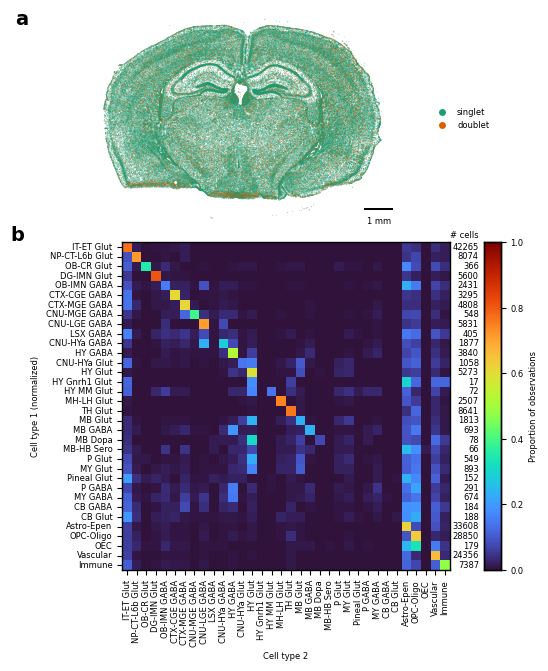

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(18 * CM, 17 * CM), height_ratios=[1, 1.5])


ax = axs[0]

adata.obs["cell"] = pd.Series(
    np.where(
        mapmycells_df_top["family_name"] == mapmycells_df_bottom["family_name"],
        "singlet",
        "doublet",
    ),
    index=mapmycells_df_top.index,
)


scatter = sns.scatterplot(
    data=adata.obs,
    x="x_centroid",
    y="y_centroid",
    hue="cell",
    s=0.2,
    ax=ax,
    lw=0,
    palette="Dark2",
    rasterized=True,
)
scatter.legend(loc="center left", bbox_to_anchor=(1.1, 0.5), frameon=False)
for handle in scatter.legend_.legend_handles:
    handle.set_markersize(5)


ax.add_artist(ScaleBar(1, units="um", length_fraction=0.1, loc="lower right"))
ax.set_axis_off()
ax.set_aspect("equal", adjustable="box")

_ = plot_celltype_consistency(
    celltype_combinations, counts.to_numpy(), fig_ax=(fig, axs[1]), offset=3
)

axs[0].text(-0.2, 1, "a", transform=axs[0].transAxes, **label_kwargs)
axs[1].text(-0.3, 1.05, "b", transform=axs[1].transAxes, **label_kwargs)

fig.tight_layout(h_pad=0)

# fig.savefig("celltype_combinations.png", **save_kwargs)
fig.savefig("celltype_combinations.svg", **save_kwargs)

In [18]:
from scipy.ndimage import gaussian_filter

glial_classes = ["30 Astro-Epen", "33 Vascular", "31 OPC-Oligo", "34 Immune"]

class_color_dict = {
    "Dopa": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "Glut": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "Inh": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "Astro-Epen": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "Vascular": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "OPC-Oligo": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "Immune": (1.0, 1.0, 0.7019607843137254),
    "OEC": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
}

c_glial = class_color_dict["OPC-Oligo"]
c_Inh = class_color_dict["Inh"]

xlim_ca1 = (2_900, 7_000)
ylim_ca1 = (5_000, 5_460)

is_dense = (gaussian_filter(signal_strength, 15) > 2.5)[
    adata.obs["y_centroid"].astype(int), adata.obs["x_centroid"].astype(int)
]
in_view = adata.obs["x_centroid"].between(*xlim_ca1) & adata.obs["y_centroid"].between(
    *ylim_ca1
)

is_ca1 = (
    is_dense
    & in_view
    & ~adata.obs["x_centroid"].between(xlim_ca1[0] + 1750, xlim_ca1[0] + 2250)
)

ca1_df = adata.obs[is_ca1]
class_top = mapmycells_df_top.loc[is_ca1, "class_name"]
class_bottom = mapmycells_df_bottom.loc[is_ca1, "class_name"]

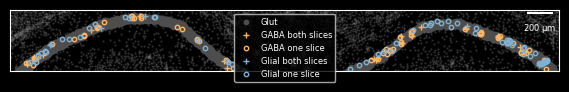

In [19]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(18 * CM, 4 * CM))

    kwargs = dict(x="x_centroid", y="y_centroid", ax=ax)

    circle_size = 10
    cross_size = 25

    adata.obs[in_view].plot.scatter(c="darkgrey", s=0.5, alpha=0.2, **kwargs)
    adata.obs[is_ca1].plot.scatter(
        color=(0.3, 0.3, 0.3), s=10, alpha=1.0, label="Glut", **kwargs
    )

    ca1_df[
        class_top.str.contains("GABA") & class_bottom.str.contains("GABA")
    ].plot.scatter(
        marker="+",
        color=c_Inh,
        linewidth=1,
        s=cross_size,
        label="GABA both slices",
        **kwargs,
    )

    ca1_df[
        class_top.str.contains("GABA") ^ class_bottom.str.contains("GABA")
    ].plot.scatter(
        color=(0, 0, 0, 0),
        edgecolors=c_Inh,
        linewidth=1,
        s=circle_size,
        label="GABA one slice",
        **kwargs,
    )

    ca1_df[
        class_top.isin(glial_classes) & class_bottom.isin(glial_classes)
    ].plot.scatter(
        marker="+",
        color=c_glial,
        linewidth=1,
        s=cross_size,
        label="Glial both slices",
        **kwargs,
    )

    ca1_df[
        class_top.isin(glial_classes) ^ class_bottom.isin(glial_classes)
    ].plot.scatter(
        color=(0, 0, 0, 0),
        edgecolors=c_glial,
        linewidth=1,
        s=circle_size,
        label="Glial one slice",
        **kwargs,
    )

    plt.legend(loc="upper center")

    ax.set(
        facecolor="k",
        xlim=xlim_ca1,
        ylim=ylim_ca1,
        aspect="equal",
        xlabel="",
        ylabel="",
        yticks=[],
        xticks=[],
    )

    ax.add_artist(
        ScaleBar(
            1,
            units="um",
            frameon=False,
            color="w",
            length_fraction=0.1,
            height_fraction=0.04,
        )
    )

    fig.savefig("ca1_cell_scatter.svg", **save_kwargs)

In [20]:
ca1_df_top = mapmycells_df_top[is_ca1].copy()
ca1_df_bottom = mapmycells_df_bottom[is_ca1].copy()

all_classes = sorted(set(ca1_df_top["family_name"]) | set(ca1_df_bottom["family_name"]))


global_prediction_coherence = (
    ca1_df_top.family_name.astype(str) == ca1_df_bottom.family_name.astype(str)
)[~((ca1_df_top.family_name == "Glut") & (ca1_df_bottom.family_name == "Glut"))].mean()

celltype_combinations, counts = celltype_consistency(
    ca1_df_top["family_name"], ca1_df_bottom["family_name"], all_classes
)

/tmp/ipykernel_895882/3394838482.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ca1_df_top = mapmycells_df_top[is_ca1].copy()
/tmp/ipykernel_895882/3394838482.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ca1_df_bottom = mapmycells_df_bottom[is_ca1].copy()


0.20 non-glut coherent


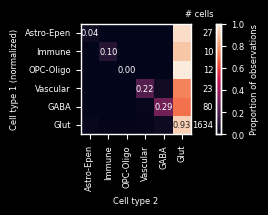

In [21]:
axis_ticks = ["Astro-Epen", "Immune", "OPC-Oligo", "Vascular", "GABA", "Glut"]

with plt.style.context("dark_background"):
    fig = plot_celltype_consistency(
        celltype_combinations.loc[axis_ticks, axis_ticks],
        counts.loc[axis_ticks],
        figsize=(13 * CM, 5.5 * CM),
        cmap="rocket",
        f=".2f",
        offset=1.2,
    )
    fig.tight_layout()

    plt.yticks(rotation=0)
    plt.xticks(rotation=90)

    # border around colorbar
    for ax in fig.axes:
        for spine in ax.spines.values():
            spine.set_edgecolor("white")

    fig.savefig("ca1_inh_combinations.svg", **save_kwargs)

print(f"{global_prediction_coherence:.2f} non-glut coherent")

#### A quantification of ovrlpy, using the signal integrity map:

In [22]:
# perform statistics between coherent and incoherent samples:
from scipy.stats import normaltest, ttest_ind

print("Mean integrity values:")

gaba_coherent_integrity_samples = ca1_df.loc[
    class_top.str.contains("GABA") & class_bottom.str.contains("GABA"),
    "nuclear_integrity",
]
gaba_incoherent_integrity_samples = ca1_df.loc[
    class_top.str.contains("GABA") ^ class_bottom.str.contains("GABA"),
    "nuclear_integrity",
]

# Test for normality:
print(f"GABA coherent normality: {normaltest(gaba_coherent_integrity_samples)}")
print(f"GABA incoherent normality: {normaltest(gaba_incoherent_integrity_samples)}")
ttest_gaba = ttest_ind(
    gaba_coherent_integrity_samples, gaba_incoherent_integrity_samples, equal_var=False
)

print(f"GABA coherent: {gaba_coherent_integrity_samples.mean()}")
print(f"GABA incoherent: {gaba_incoherent_integrity_samples.mean()}")
print(f"GABA t-test: {ttest_gaba}")
print()

glial_coherent_integrity_samples = ca1_df[
    class_top.isin(glial_classes) & class_bottom.isin(glial_classes)
]
glial_incoherent_integrity_samples = ca1_df[
    class_top.isin(glial_classes) ^ class_bottom.isin(glial_classes)
]

# Test for normality:
print(
    f"Glial coherent normality: {normaltest(glial_coherent_integrity_samples['nuclear_integrity'])}"
)
print(
    f"Glial incoherent normality: {normaltest(glial_incoherent_integrity_samples['nuclear_integrity'])}"
)
ttest_glial = ttest_ind(
    glial_coherent_integrity_samples["nuclear_integrity"],
    glial_incoherent_integrity_samples["nuclear_integrity"],
    equal_var=False,
)

print(f"Glial coherent: {glial_coherent_integrity_samples['nuclear_integrity'].mean()}")
print(
    f"Glial incoherent: {glial_incoherent_integrity_samples['nuclear_integrity'].mean()}"
)
print(f"Glial t-test: {ttest_glial}")

Mean integrity values:
GABA coherent normality: NormaltestResult(statistic=7.945994049357996, pvalue=0.018816953667722507)
GABA incoherent normality: NormaltestResult(statistic=3.369175012485827, pvalue=0.18552094240539566)
GABA coherent: 0.8587098873179891
GABA incoherent: 0.6807025017445547
GABA t-test: TtestResult(statistic=4.664402469831313, pvalue=2.5247401584649446e-05, df=47.73850188261685)

Glial coherent normality: NormaltestResult(statistic=nan, pvalue=nan)
Glial incoherent normality: NormaltestResult(statistic=23.91330977240265, pvalue=6.416390112350624e-06)
Glial coherent: 0.7910075102533612
Glial incoherent: 0.7320886547748859
Glial t-test: TtestResult(statistic=0.9291040397615901, pvalue=0.38005587010641073, df=7.987742834330859)


/tmp/ipykernel_895882/4059172317.py:36: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f"Glial coherent normality: {normaltest(glial_coherent_integrity_samples['nuclear_integrity'])}"


In [23]:
from scipy.stats import mannwhitneyu

mwu_gaba = mannwhitneyu(
    gaba_coherent_integrity_samples, gaba_incoherent_integrity_samples, method="auto"
)
mwu_glial = mannwhitneyu(
    glial_coherent_integrity_samples["mean_integrity"],
    glial_incoherent_integrity_samples["mean_integrity"],
    method="auto",
)

print(f"GABA MWU: {mwu_gaba}")
print(f"Glial MWU: {mwu_glial}")

GABA MWU: MannwhitneyuResult(statistic=1050.0, pvalue=2.8098965984410806e-05)
Glial MWU: MannwhitneyuResult(statistic=162.0, pvalue=0.22187426307253494)


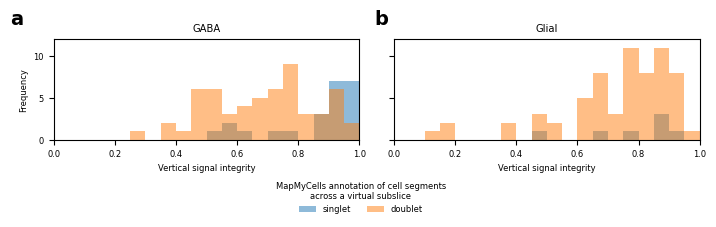

In [24]:
fig, axs = plt.subplots(ncols=2, figsize=(18 * CM, 5 * CM), sharey=True, sharex=True)

title = "MapMyCells annotation of cell segments\nacross a virtual subslice"
vsi = "Vertical signal integrity"

gaba_coherent_integrity_samples.plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="singlet", ax=axs[0]
)
gaba_incoherent_integrity_samples.plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="doublet", ax=axs[0]
)
axs[0].set(ylabel="Frequency", xlabel=vsi, title="GABA")

legend = fig.legend(
    title=title, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.2)
)
legend.get_title().set_ha("center")

glial_coherent_integrity_samples["nuclear_integrity"].plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="singlet", ax=axs[1]
)
glial_incoherent_integrity_samples["nuclear_integrity"].plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="doublet", ax=axs[1]
)
axs[1].set(xlabel=vsi, title="Glial", xlim=(0, 1), ylim=(0, 12))
axs[0].set_yticks([0, 5, 10])
axs[0].minorticks_off()


y_off = 1.3
axs[0].text(-0.1, y_off, "a", transform=axs[0].transAxes, **label_kwargs)
axs[1].text(-0.02, y_off, "b", transform=axs[1].transAxes, **label_kwargs)

fig.tight_layout()
fig.savefig("ca1_integrity_histograms.png", dpi=600, bbox_inches="tight")

#### Print cell segments from top-bottom-missmatches with outlines:

In [25]:
cell_boundaries = pd.read_parquet(data_folder / "cell_boundaries.parquet")
cell_boundaries["cell_id"] = cell_boundaries["cell_id"].astype(str).astype("category")

nucleus_boundaries = pd.read_parquet(data_folder / "nucleus_boundaries.parquet")
nucleus_boundaries["cell_id"] = (
    nucleus_boundaries["cell_id"].astype(str).astype("category")
)

In [26]:
gene_group_df = pd.read_csv(
    data_folder / "Xenium_V1_FF_Mouse_Brain_MultiSection_Input_gene_groups.csv",
    header=0,
    index_col=0,
    usecols=[0, 1],
)
gene_group_df["idx"] = range(len(gene_group_df))

In [27]:
marker_color_dict = {
    "Neurons": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "Endothelial": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "Astrocytes": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "Oligodendrocytes": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "Microglia": (1.0, 1.0, 0.7019607843137254),
}

In [28]:
def plot_cells_in_window(
    x, y, window_size, plot_markers=True, tr_segments=True, figsize=(9 * CM, 4.5 * CM)
):
    xlim = (x - window_size, x + window_size)
    ylim = (y - window_size, y + window_size)

    xlim_px = (int(xlim[0]), int(xlim[1]) + 1)
    ylim_px = (int(ylim[0]), int(ylim[1]) + 1)

    ax_kwargs = dict(
        xticks=[],
        yticks=[],
        aspect="equal",
        facecolor="black",
        ylim=ylim_px,
        xlim=xlim_px,
    )
    line_kwargs = dict(color="white", linewidth=0.7)

    in_window_ids = cell_boundaries.loc[
        lambda df: df["vertex_x"].between(*xlim) & df["vertex_y"].between(*ylim),
        "cell_id",
    ].unique()

    in_window_top_df = mapmycells_df_top.loc[in_window_ids]
    in_window_bottom_df = mapmycells_df_bottom.loc[in_window_ids]

    polygons_cell = {}
    polygons_nucleus = {}
    for cell_id in in_window_ids:
        polygons_cell[cell_id] = Polygon(
            cell_boundaries.loc[
                cell_boundaries["cell_id"] == cell_id, ["vertex_x", "vertex_y"]
            ].to_numpy()
        )
        polygons_nucleus[cell_id] = Polygon(
            nucleus_boundaries.loc[
                nucleus_boundaries["cell_id"] == cell_id, ["vertex_x", "vertex_y"]
            ].to_numpy()
        )

    fig1, axs = plt.subplots(1, 2, figsize=figsize)

    for cell_id in in_window_ids:
        x_verteces, y_verteces = polygons_cell[cell_id].exterior.xy
        axs[0].plot(x_verteces, y_verteces, "-", **line_kwargs)
        axs[1].plot(x_verteces, y_verteces, "-", **line_kwargs)

        x_verteces, y_verteces = polygons_nucleus[cell_id].exterior.xy
        axs[0].fill(
            x_verteces,
            y_verteces,
            color=class_color_dict[in_window_top_df.loc[cell_id, "family_name"]],
        )
        axs[1].fill(
            x_verteces,
            y_verteces,
            color=class_color_dict[in_window_bottom_df.loc[cell_id, "family_name"]],
        )

    for ax in axs:
        ax.set(**ax_kwargs)

    fig1.legend(
        handles=[
            plt.scatter([], [], color=color, label=class_name)
            for class_name, color in class_color_dict.items()
        ],
        bbox_to_anchor=(0.9, 0.2),
        frameon=False,
        loc="lower left",
    )

    if not plot_markers:
        return fig1

    subset_df = coordinate_df[
        coordinate_df["x"].between(*xlim) & coordinate_df["y"].between(*ylim)
    ]

    fig2, axs = plt.subplots(1, 2, figsize=figsize)

    scatter_kwargs = dict(s=2, marker=".", lw=0)

    for marker_type in marker_color_dict.keys():
        subset_marker_df = subset_df[
            subset_df["gene"].isin(
                gene_group_df[gene_group_df["group"] == marker_type].index
            )
        ]
        subset_marker_df[
            subset_marker_df["z"] > subset_marker_df["z_center"]
        ].plot.scatter(
            "x", "y", color=marker_color_dict[marker_type], ax=axs[0], **scatter_kwargs
        )
        subset_marker_df[
            subset_marker_df["z"] < subset_marker_df["z_center"]
        ].plot.scatter(
            "x", "y", color=marker_color_dict[marker_type], ax=axs[1], **scatter_kwargs
        )

    if tr_segments:
        for cell_id in in_window_ids:
            x_verteces, y_verteces = polygons_cell[cell_id].exterior.xy
            axs[0].plot(x_verteces, y_verteces, "-", **line_kwargs)
            axs[1].plot(x_verteces, y_verteces, "-", **line_kwargs)

    for ax in axs:
        ax.set(xlabel=None, ylabel=None, **ax_kwargs)

    fig2.legend(
        handles=[
            plt.scatter([], [], color=color, label=marker_name)
            for marker_name, color in marker_color_dict.items()
        ],
        bbox_to_anchor=(0.9, 0.2),
        frameon=False,
        loc="lower left",
    )

    return fig1, fig2

In [29]:
inh_classes = {x: "Inh" for x in ["GABA", "Sero"]}

classes = {
    x: x for x in mapmycells_df_bottom["family_name"].cat.categories
} | inh_classes

mapmycells_df_bottom["family_name"] = (
    mapmycells_df_bottom["family_name"].map(classes).astype("category")
)
mapmycells_df_top["family_name"] = (
    mapmycells_df_top["family_name"].map(classes).astype("category")
)

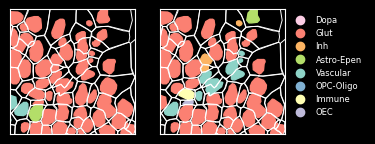

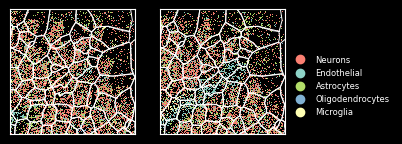

In [30]:
x, y = 6900, 5080

window_size = 40

with plt.style.context("dark_background"):
    fig1, fig2 = plot_cells_in_window(x, y, window_size)

    fig1.savefig("ca1_MMC_outlines.svg", **save_kwargs)
    fig2.savefig("ca1_MMC_markers.svg", **save_kwargs)

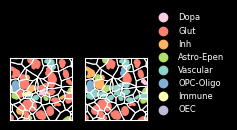

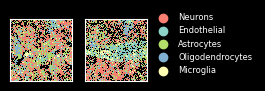

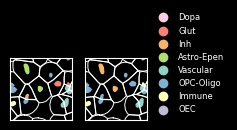

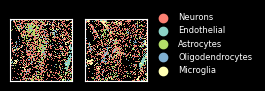

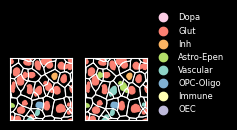

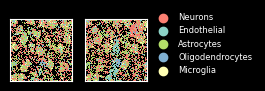

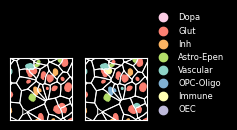

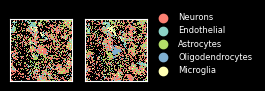

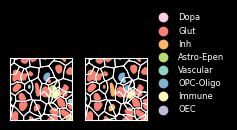

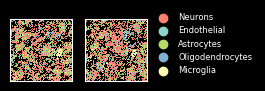

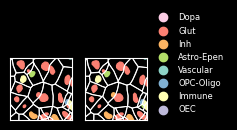

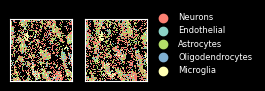

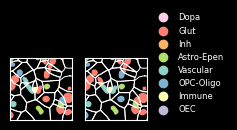

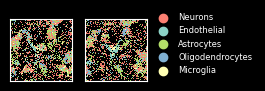

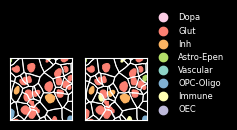

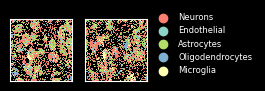

In [31]:
doublet_df = brain.detect_doublets(min_signal=3, integrity_sigma=2)

n_cases = 8

with plt.style.context("dark_background"):
    for i in range(n_cases):
        x, y = doublet_df[["x", "y"]].row(i)

        fig1, fig2 = plot_cells_in_window(
            x, y, window_size, tr_segments=False, figsize=(4.5 * CM, 2.8 * CM)
        )
        for fig in [fig1, fig2]:
            for ax in fig.axes:
                ax.invert_xaxis()
                ax.invert_yaxis()

        for ax in fig2.axes[:2]:
            for c in ax.collections:
                c.set_rasterized(True)

        fig1.savefig(f"overlaps-{i + 1}_segments.svg", **save_kwargs)
        fig2.savefig(f"overlaps-{i + 1}_transcripts.svg", **save_kwargs)

### Visualizing doublet embedding behavior in UMAP space: 

In [32]:
from sklearn.decomposition import PCA
from umap import UMAP

random_state = 42


umap = UMAP(n_components=2, n_neighbors=20, random_state=random_state)
pca = PCA(n_components=30, random_state=random_state)

pca_global = pca.fit_transform(adata.X)
embedding_global = umap.fit_transform(pca_global)

pca_cleaned = pca.fit_transform(adata[adata.obs["mean_integrity"] > 0.7, :].X)
embedding_cleaned = umap.fit_transform(pca_cleaned)

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [33]:
mapmycells_df = read_mapmycells_zip(
    "mapmycells/whole_count_mtx_10xWholeMouseBrain(CCN20230722)_CorrelationMapping_UTC_1753174321681.zip"
)
mapmycells_df.index = mapmycells_df.index.astype(str)

plot_df = pd.DataFrame(
    {"x": embedding_global[:, 0], "y": embedding_global[:, 1]}, index=adata.obs_names
)
plot_df["mean_integrity"] = adata.obs["mean_integrity"]
plot_df["class_name"] = mapmycells_df["class_name"]
plot_df["cluster_name"] = mapmycells_df["cluster_name"].astype("category")

plot_df["class_short"] = plot_df["class_name"].str.split(" ").str[-1]
plot_df.loc[plot_df["cluster_name"].str.contains("VLMC", na=False), "class_short"] = (
    "VLMC"
)
plot_df["class_short"] = plot_df["class_short"].astype("category")

plot_clean_df = plot_df.loc[plot_df["mean_integrity"] > 0.7].copy()
plot_clean_df[["x", "y"]] = embedding_cleaned

In [34]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

not_na_clean = ~plot_clean_df["cluster_name"].isna()
not_na = ~plot_df["cluster_name"].isna()

silhouette_clean = silhouette_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "cluster_name"]
)
silhouette = silhouette_score(
    pca_global[not_na, :], plot_df.loc[not_na, "cluster_name"]
)
db_clean = davies_bouldin_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "cluster_name"]
)
db = davies_bouldin_score(pca_global[not_na, :], plot_df.loc[not_na, "cluster_name"])
ch_clean = calinski_harabasz_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "cluster_name"]
)
ch = calinski_harabasz_score(pca_global[not_na, :], plot_df.loc[not_na, "cluster_name"])

print(f"Silhouette score: {silhouette:.3f}")
print(f"Silhouette score (w/o doublet): {silhouette_clean:.3f}")
print(f"Calinski Harabasz: {ch:.3f}")
print(f"Calinski Harabasz (w/o doublet): {ch_clean:.3f}")
print(f"Davies Bouldin: {db:.3f}")
print(f"Davies Bouldin (w/o doublet): {db_clean:.3f}")

Silhouette score: -0.364
Silhouette score (w/o doublet): -0.322
Calinski Harabasz: 69.438
Calinski Harabasz (w/o doublet): 74.266
Davies Bouldin: 4.344
Davies Bouldin (w/o doublet): 4.146


In [35]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

not_na_clean = ~plot_clean_df["class_name"].isna()
not_na = ~plot_df["class_name"].isna()

silhouette_clean = silhouette_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "class_name"]
)
silhouette = silhouette_score(pca_global[not_na, :], plot_df.loc[not_na, "class_name"])
db_clean = davies_bouldin_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "class_name"]
)
db = davies_bouldin_score(pca_global[not_na, :], plot_df.loc[not_na, "class_name"])
ch_clean = calinski_harabasz_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "class_name"]
)
ch = calinski_harabasz_score(pca_global[not_na, :], plot_df.loc[not_na, "class_name"])

print(f"Silhouette score: {silhouette:.3f}")
print(f"Silhouette score (w/o doublet): {silhouette_clean:.3f}")
print(f"Calinski Harabasz: {ch:.3f}")
print(f"Calinski Harabasz (w/o doublet): {ch_clean:.3f}")
print(f"Davies Bouldin: {db:.3f}")
print(f"Davies Bouldin (w/o doublet): {db_clean:.3f}")

Silhouette score: -0.186
Silhouette score (w/o doublet): -0.150
Calinski Harabasz: 2465.216
Calinski Harabasz (w/o doublet): 2187.778
Davies Bouldin: 4.120
Davies Bouldin (w/o doublet): 3.692


In [36]:
plot_df = plot_df.assign(
    cell=lambda df: np.where(df["mean_integrity"] > 0.7, "singlet", "doublet")
)

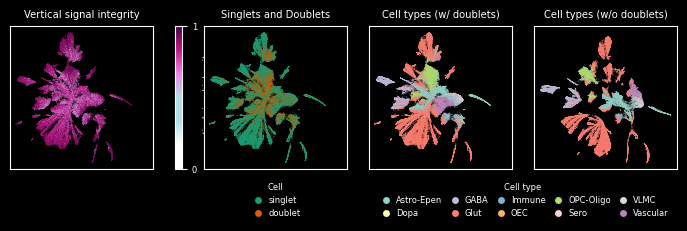

In [37]:
with plt.style.context("dark_background"):
    fig = plt.figure(figsize=(18 * CM, 5.5 * CM))
    gs = matplotlib.gridspec.GridSpec(
        2, 5, figure=fig, width_ratios=[1, 0.05, 1, 1, 1], height_ratios=[1, 0.05]
    )

    scatter_kwargs = dict(x="x", y="y", s=0.1, lw=0, rasterized=True)
    legend_kwargs = dict(
        loc="upper center", frameon=False, columnspacing=0.5, handletextpad=0.2
    )
    axs = []

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    sns.scatterplot(
        data=plot_df,
        hue="mean_integrity",
        palette=BIH_CMAP,
        hue_norm=matplotlib.colors.Normalize(vmin=0, vmax=1),
        ax=ax,
        legend=False,
        **scatter_kwargs,
    )
    ax.set(title="Vertical signal integrity")

    fig.colorbar(
        plt.cm.ScalarMappable(norm=ax.collections[0].norm, cmap=BIH_CMAP),
        ax=ax,
        cax=cax,
        label="vertical signal integrity",
        ticks=[0, 1],
    )
    axs.append(ax)

    ax = fig.add_subplot(gs[0, 2])
    lax = fig.add_subplot(gs[1, 2])
    sc = sns.scatterplot(
        data=plot_df, hue="cell", palette="Dark2", ax=ax, **scatter_kwargs
    )
    ax.set(title="Singlets and Doublets")
    handles, labels = ax.get_legend_handles_labels()
    legened = lax.legend(handles, labels, ncols=1, title="Cell", **legend_kwargs)
    legened.get_title().set_ha("left")
    for handle in legened.legend_handles:
        handle.set_markersize(5)
    ax.legend_.remove()
    lax.axis("off")

    axs.append(ax)

    ax = fig.add_subplot(gs[0, 3])
    lax = fig.add_subplot(gs[1, 3:5])
    sc = sns.scatterplot(
        data=plot_df, hue="class_short", palette="Set3", ax=ax, **scatter_kwargs
    )
    ax.set(title="Cell types (w/ doublets)")
    handles, labels = ax.get_legend_handles_labels()
    legened = lax.legend(handles, labels, ncols=5, title="Cell type", **legend_kwargs)
    legened.get_title().set_ha("left")
    for handle in legened.legend_handles:
        handle.set_markersize(5)
    ax.legend_.remove()
    lax.axis("off")

    axs.append(ax)

    ax = fig.add_subplot(gs[0, 4])
    sns.scatterplot(
        data=plot_clean_df,
        hue="class_short",
        palette="Set3",
        ax=ax,
        legend=False,
        **scatter_kwargs,
    )
    ax.set(title="Cell types (w/o doublets)")
    axs.append(ax)

    for i, ax in enumerate(axs):
        ax.set_aspect("equal", adjustable="box")
        ax.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
        ax.axis("square")

    fig.tight_layout(h_pad=0, w_pad=-1)
    fig.savefig("UMAP.svg", **save_kwargs)

#### Nuclear transcripts only 

In [38]:
nuclear_adata = ad.read_h5ad("nuclear_count_mtx.h5ad")

nuclear_adata.obs = nuclear_adata.obs.join(adata.obs)

In [39]:
from sklearn.decomposition import PCA
from umap import UMAP

random_state = 42


umap = UMAP(n_components=2, n_neighbors=20, random_state=random_state)
pca = PCA(n_components=30, random_state=random_state)

pca_global = pca.fit_transform(nuclear_adata.X)
embedding_global = umap.fit_transform(pca_global)

pca_cleaned = pca.fit_transform(
    nuclear_adata[nuclear_adata.obs["mean_integrity"] > 0.7, :].X
)
embedding_cleaned = umap.fit_transform(pca_cleaned)

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [40]:
mapmycells_df = read_mapmycells_zip(
    "mapmycells/nuclear_count_mtx_10xWholeMouseBrain(CCN20230722)_CorrelationMapping_UTC_1753775660059.zip"
)
mapmycells_df.index = mapmycells_df.index.astype(str)

plot_df = pd.DataFrame(
    {"x": embedding_global[:, 0], "y": embedding_global[:, 1]},
    index=nuclear_adata.obs_names,
)
plot_df["mean_integrity"] = nuclear_adata.obs["mean_integrity"]
plot_df["class_name"] = mapmycells_df["class_name"]
plot_df["cluster_name"] = mapmycells_df["cluster_name"].astype("category")

plot_df["class_short"] = plot_df["class_name"].str.split(" ").str[-1]
plot_df.loc[plot_df["cluster_name"].str.contains("VLMC", na=False), "class_short"] = (
    "VLMC"
)
plot_df["class_short"] = plot_df["class_short"].astype("category")

plot_clean_df = plot_df.loc[plot_df["mean_integrity"] > 0.7].copy()
plot_clean_df[["x", "y"]] = embedding_cleaned

In [41]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

not_na_clean = ~plot_clean_df["cluster_name"].isna()
not_na = ~plot_df["cluster_name"].isna()

silhouette_clean = silhouette_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "cluster_name"]
)
silhouette = silhouette_score(
    pca_global[not_na, :], plot_df.loc[not_na, "cluster_name"]
)
db_clean = davies_bouldin_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "cluster_name"]
)
db = davies_bouldin_score(pca_global[not_na, :], plot_df.loc[not_na, "cluster_name"])
ch_clean = calinski_harabasz_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "cluster_name"]
)
ch = calinski_harabasz_score(pca_global[not_na, :], plot_df.loc[not_na, "cluster_name"])

print(f"Silhouette score: {silhouette:.3f}")
print(f"Silhouette score (w/o doublet): {silhouette_clean:.3f}")
print(f"Calinski Harabasz: {ch:.3f}")
print(f"Calinski Harabasz (w/o doublet): {ch_clean:.3f}")
print(f"Davies Bouldin: {db:.3f}")
print(f"Davies Bouldin (w/o doublet): {db_clean:.3f}")

Silhouette score: -0.337
Silhouette score (w/o doublet): -0.281
Calinski Harabasz: 84.437
Calinski Harabasz (w/o doublet): 87.632
Davies Bouldin: 4.061
Davies Bouldin (w/o doublet): 3.993


In [42]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

not_na_clean = ~plot_clean_df["class_name"].isna()
not_na = ~plot_df["class_name"].isna()

silhouette_clean = silhouette_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "class_name"]
)
silhouette = silhouette_score(pca_global[not_na, :], plot_df.loc[not_na, "class_name"])
db_clean = davies_bouldin_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "class_name"]
)
db = davies_bouldin_score(pca_global[not_na, :], plot_df.loc[not_na, "class_name"])
ch_clean = calinski_harabasz_score(
    pca_cleaned[not_na_clean, :], plot_clean_df.loc[not_na_clean, "class_name"]
)
ch = calinski_harabasz_score(pca_global[not_na, :], plot_df.loc[not_na, "class_name"])

print(f"Silhouette score: {silhouette:.3f}")
print(f"Silhouette score (w/o doublet): {silhouette_clean:.3f}")
print(f"Calinski Harabasz: {ch:.3f}")
print(f"Calinski Harabasz (w/o doublet): {ch_clean:.3f}")
print(f"Davies Bouldin: {db:.3f}")
print(f"Davies Bouldin (w/o doublet): {db_clean:.3f}")

Silhouette score: -0.167
Silhouette score (w/o doublet): -0.130
Calinski Harabasz: 3157.642
Calinski Harabasz (w/o doublet): 2639.263
Davies Bouldin: 4.300
Davies Bouldin (w/o doublet): 3.846


In [43]:
plot_df = plot_df.assign(
    cell=lambda df: np.where(df["mean_integrity"] > 0.7, "singlet", "doublet")
)

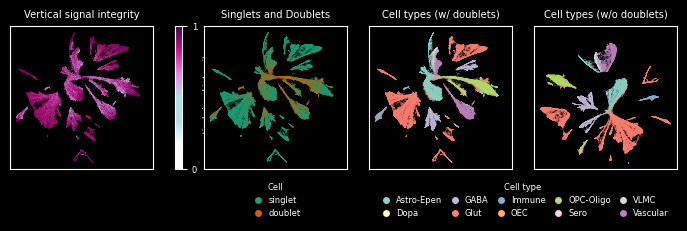

In [44]:
with plt.style.context("dark_background"):
    fig = plt.figure(figsize=(18 * CM, 5.5 * CM))
    gs = matplotlib.gridspec.GridSpec(
        2, 5, figure=fig, width_ratios=[1, 0.05, 1, 1, 1], height_ratios=[1, 0.05]
    )

    scatter_kwargs = dict(x="x", y="y", s=0.1, lw=0, rasterized=True)
    legend_kwargs = dict(
        loc="upper center", frameon=False, columnspacing=0.5, handletextpad=0.2
    )
    axs = []

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    sns.scatterplot(
        data=plot_df,
        hue="mean_integrity",
        palette=BIH_CMAP,
        hue_norm=matplotlib.colors.Normalize(vmin=0, vmax=1),
        ax=ax,
        legend=False,
        **scatter_kwargs,
    )
    ax.set(title="Vertical signal integrity")

    fig.colorbar(
        plt.cm.ScalarMappable(norm=ax.collections[0].norm, cmap=BIH_CMAP),
        ax=ax,
        cax=cax,
        label="vertical signal integrity",
        ticks=[0, 1],
    )
    axs.append(ax)

    ax = fig.add_subplot(gs[0, 2])
    lax = fig.add_subplot(gs[1, 2])
    sc = sns.scatterplot(
        data=plot_df, hue="cell", palette="Dark2", ax=ax, **scatter_kwargs
    )
    ax.set(title="Singlets and Doublets")
    handles, labels = ax.get_legend_handles_labels()
    legened = lax.legend(handles, labels, ncols=1, title="Cell", **legend_kwargs)
    legened.get_title().set_ha("left")
    for handle in legened.legend_handles:
        handle.set_markersize(5)
    ax.legend_.remove()
    lax.axis("off")

    axs.append(ax)

    ax = fig.add_subplot(gs[0, 3])
    lax = fig.add_subplot(gs[1, 3:5])
    sc = sns.scatterplot(
        data=plot_df, hue="class_short", palette="Set3", ax=ax, **scatter_kwargs
    )
    ax.set(title="Cell types (w/ doublets)")
    handles, labels = ax.get_legend_handles_labels()
    legened = lax.legend(handles, labels, ncols=5, title="Cell type", **legend_kwargs)
    legened.get_title().set_ha("left")
    for handle in legened.legend_handles:
        handle.set_markersize(5)
    ax.legend_.remove()
    lax.axis("off")

    axs.append(ax)

    ax = fig.add_subplot(gs[0, 4])
    sns.scatterplot(
        data=plot_clean_df,
        hue="class_short",
        palette="Set3",
        ax=ax,
        legend=False,
        **scatter_kwargs,
    )
    ax.set(title="Cell types (w/o doublets)")
    axs.append(ax)

    for i, ax in enumerate(axs):
        ax.set_aspect("equal", adjustable="box")
        ax.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
        ax.axis("square")

    fig.tight_layout(h_pad=0, w_pad=-1)
    fig.savefig("UMAP_nuclear.svg", **save_kwargs)